In [44]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Read dfs
# IV df
modeled_iv_df = pd.read_csv('../results/combined_iv.csv')

# Underlying df
spy_prices_df = pd.read_parquet('../data/processed/spy_prices.parquet')

# Equity dfs
xgb_equity_df = pd.read_csv('../results/equity_logs/XGB_equity.csv')
historical_equity_df = pd.read_csv('../results/equity_logs/historical_equity.csv')
garch_equity_df = pd.read_csv('../results/equity_logs/GARCH_equity.csv')

# Trade log dfs
xgb_trade_log_df = pd.read_csv('../results/trade_logs/XGB_trade_log.csv')
garch_trade_log_df = pd.read_csv('../results/trade_logs/GARCH_trade_log.csv')
historical_trade_log_df = pd.read_csv('../results/trade_logs/historical_trade_log.csv')

# Expiry log dfs
xgb_expiry_log_df = pd.read_csv('../results/expiry_logs/XGB_expiry_log.csv')
garch_expiry_log_df = pd.read_csv('../results/expiry_logs/GARCH_expiry_log.csv')
historical_expiry_log_df = pd.read_csv('../results/expiry_logs/historical_expiry_log.csv')

# Early exit dfs
xgb_early_exit_df = pd.read_csv('../results/early_exit_logs/XGB_early_exit_log.csv')
garch_early_exit_df = pd.read_csv('../results/early_exit_logs/GARCH_early_exit_log.csv')
historical_early_exit_df = pd.read_csv('../results/early_exit_logs/historical_early_exit_log.csv')

In [45]:
# =============================================================================
# Forward Realized Volatility Comparison
# Compare model forecasts (minus VRP) to actual forward-looking realized vol
# =============================================================================

# Calculate log returns from SPY prices
spy_prices_df = spy_prices_df.sort_values('date').reset_index(drop=True)
spy_prices_df['log_return'] = np.log(spy_prices_df['close'] / spy_prices_df['close'].shift(1))

# Calculate forward-looking 30-day realized volatility (annualized, in decimal)
spy_prices_df['forward_rv'] = (
    spy_prices_df['log_return']
    .shift(-1)  # Start from tomorrow
    .rolling(window=30, min_periods=30)
    .std()
    .shift(-29)  # Align to today's date (30 days forward from today)
    * np.sqrt(252)
)

# Merge forward RV into modeled_iv_df
modeled_iv_df['date'] = pd.to_datetime(modeled_iv_df['date'])
spy_prices_df['date'] = pd.to_datetime(spy_prices_df['date'])
analysis_df = modeled_iv_df.merge(spy_prices_df[['date', 'forward_rv']], on='date', how='left')

# Subtract VRP from modeled IVs to get RV forecasts
# (Since models forecast RV and then add VRP to estimate IV)
analysis_df['historical_rv_forecast'] = analysis_df['historical_iv'] - analysis_df['vrp_adjustment']
analysis_df['GARCH_rv_forecast'] = analysis_df['GARCH_iv'] - analysis_df['vrp_adjustment']
analysis_df['XGB_rv_forecast'] = analysis_df['XGB_iv'] - analysis_df['vrp_adjustment']

# Drop NaN rows for comparison
rv_clean = analysis_df.dropna(subset=['forward_rv', 'historical_rv_forecast', 'GARCH_rv_forecast', 'XGB_rv_forecast'])

# Calculate error metrics against forward realized volatility
rv_methods = ['historical_rv_forecast', 'GARCH_rv_forecast', 'XGB_rv_forecast']
rv_results = []

for method in rv_methods:
    y_pred = rv_clean[method]
    y_true = rv_clean['forward_rv']
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    # Also calculate bias (mean error) - positive = overestimate
    bias = (y_pred - y_true).mean()
    
    # Correlation
    corr = y_pred.corr(y_true)
    
    rv_results.append({
        'Method': method.replace('_rv_forecast', ''),
        'RMSE': rmse,
        'MAE': mae,
        'Bias': bias,
        'Correlation': corr
    })

rv_error_df = pd.DataFrame(rv_results)
print("=== Forward Realized Volatility Forecast Accuracy ===")
print(f"(Comparing model forecasts to actual 30-day forward RV, n={len(rv_clean)} days)\n")
rv_error_df


=== Forward Realized Volatility Forecast Accuracy ===
(Comparing model forecasts to actual 30-day forward RV, n=1430 days)



,Method,RMSE,MAE,Bias,Correlation
0,historical,0.122441,0.066519,0.005528,0.387919
1,GARCH,0.111067,0.066585,0.021467,0.474638
2,XGB,0.091821,0.053851,-0.028482,0.552124


In [47]:
# =============================================================================
# Regime-Conditional Performance Analysis
# Break down strategy returns by VIX volatility regimes
# =============================================================================

# Prepare equity dataframes with consistent date formatting
for df in [xgb_equity_df, garch_equity_df, historical_equity_df]:
    df['date'] = pd.to_datetime(df['date'])

# Calculate daily returns for each strategy
xgb_equity_df['daily_return'] = xgb_equity_df['equity'].pct_change()
garch_equity_df['daily_return'] = garch_equity_df['equity'].pct_change()
historical_equity_df['daily_return'] = historical_equity_df['equity'].pct_change()

# Merge VIX data for regime classification
regime_df = modeled_iv_df[['date', 'vix_close']].copy()
regime_df['date'] = pd.to_datetime(regime_df['date'])

# Define volatility regimes based on VIX levels
def classify_regime(vix):
    if vix < 12:
        return 'Low (VIX < 12)'
    elif vix < 20:
        return 'Normal (12-20)'
    elif vix < 25:
        return 'Elevated (20-25)'
    elif vix < 35:
        return 'High (25-35)'
    else:
        return 'Stress (VIX > 35)'

regime_df['regime'] = regime_df['vix_close'].apply(classify_regime)

# Merge regime data with each strategy's returns
xgb_regime = xgb_equity_df.merge(regime_df[['date', 'regime', 'vix_close']], on='date', how='left')
garch_regime = garch_equity_df.merge(regime_df[['date', 'regime', 'vix_close']], on='date', how='left')
hist_regime = historical_equity_df.merge(regime_df[['date', 'regime', 'vix_close']], on='date', how='left')

# Calculate regime-conditional statistics
def calc_regime_stats(df, strategy_name):
    results = []
    for regime in ['Low (VIX < 12)', 'Normal (12-20)', 'Elevated (20-25)', 'High (25-35)', 'Stress (VIX > 35)']:
        regime_data = df[df['regime'] == regime]['daily_return'].dropna()
        if len(regime_data) > 0:
            total_return = (1 + regime_data).prod() - 1
            mean_daily = regime_data.mean()
            std_daily = regime_data.std()
            sharpe = (mean_daily / std_daily * np.sqrt(252)) if std_daily > 0 else 0
            win_rate = (regime_data > 0).mean()
            n_days = len(regime_data)
            
            results.append({
                'Strategy': strategy_name,
                'Regime': regime,
                'Days': n_days,
                'Total Return': f"{total_return:.2%}",
                'Ann. Sharpe': f"{sharpe:.2f}",
                'Win Rate': f"{win_rate:.1%}",
                'Avg Daily': f"{mean_daily:.4%}"
            })
    return results

# Combine all strategies
all_regime_stats = []
all_regime_stats.extend(calc_regime_stats(xgb_regime, 'XGB'))
all_regime_stats.extend(calc_regime_stats(garch_regime, 'GARCH'))
all_regime_stats.extend(calc_regime_stats(hist_regime, 'Historical'))

regime_stats_df = pd.DataFrame(all_regime_stats)

# Pivot for cleaner display - separate tables for each metric
regime_order = ['Low (VIX < 12)', 'Normal (12-20)', 'Elevated (20-25)', 'High (25-35)', 'Stress (VIX > 35)']
strategy_order = ['XGB', 'GARCH', 'Historical']

# Create individual pivot tables
return_pivot = regime_stats_df.pivot(index='Regime', columns='Strategy', values='Total Return').reindex(regime_order)[strategy_order]
sharpe_pivot = regime_stats_df.pivot(index='Regime', columns='Strategy', values='Ann. Sharpe').reindex(regime_order)[strategy_order]
days_pivot = regime_stats_df.pivot(index='Regime', columns='Strategy', values='Days').reindex(regime_order)[strategy_order]

from IPython.display import display, Markdown, HTML

# Display tables side by side using HTML
display(Markdown("### Regime-Conditional Performance"))

html = f"""
<div style="display: flex; gap: 30px; flex-wrap: wrap;">
    <div>
        <p><strong>Total Return by Regime</strong></p>
        {return_pivot.to_html()}
    </div>
    <div>
        <p><strong>Annualized Sharpe by Regime</strong></p>
        {sharpe_pivot.to_html()}
    </div>
    <div>
        <p><strong>Days per Regime</strong></p>
        {days_pivot.to_html()}
    </div>
</div>
"""
display(HTML(html))


### Regime-Conditional Performance

Strategy,XGB,GARCH,Historical
Regime,,,
Low (VIX < 12),-0.69%,-1.00%,-1.05%
Normal (12-20),-16.30%,-58.30%,-41.63%
Elevated (20-25),17.95%,12.72%,12.08%
High (25-35),12.32%,3.41%,-4.85%
Stress (VIX > 35),-3.64%,8.31%,3.18%
Strategy,XGB,GARCH,Historical
Regime,,,
Low (VIX < 12),-47.26,-68.29,-39.22
Normal (12-20),-2.35,-4.57,-3.86


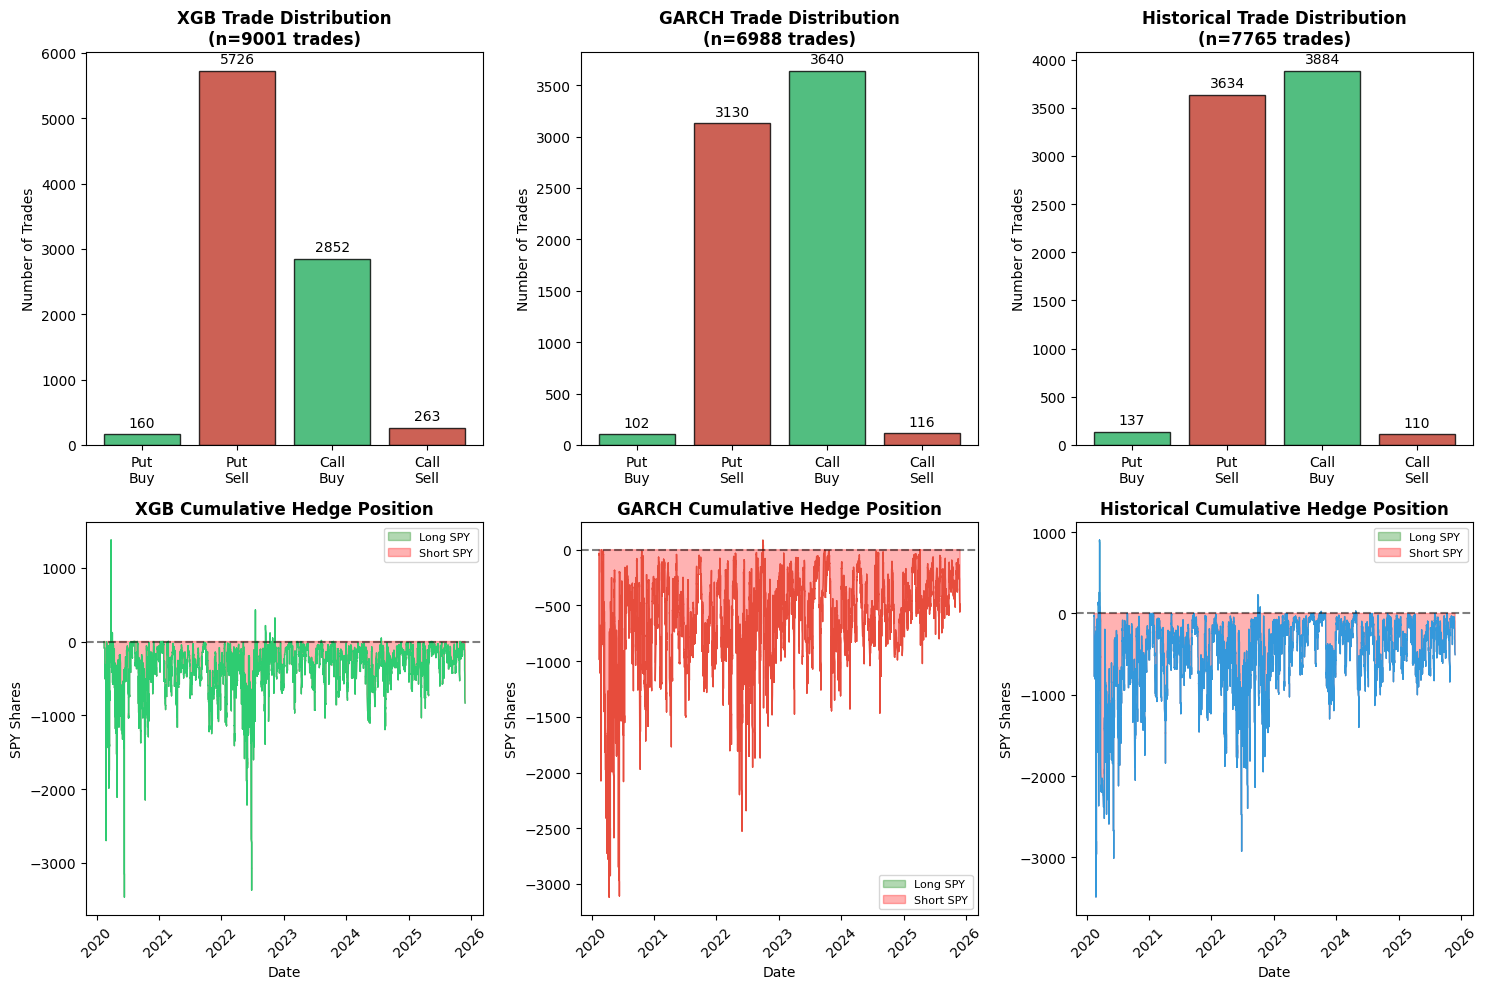

### Trade Distribution Summary

,Strategy,Total Trades,Puts,Calls,Buys,Sells
0,XGB,9001,5886 (65.4%),3115 (34.6%),3012 (33.5%),5989 (66.5%)
1,GARCH,6988,3232 (46.3%),3756 (53.7%),3742 (53.5%),3246 (46.5%)
2,Historical,7765,3771 (48.6%),3994 (51.4%),4021 (51.8%),3744 (48.2%)


In [48]:
# =============================================================================
# Trade-Level Analysis
# Distribution of trades, hedge positions, and mispricing at entry
# =============================================================================
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display, Markdown, HTML

# Black-Scholes for reconstructing theoretical prices
def bs_price(S, K, T, r, sigma, option_type):
    """Calculate Black-Scholes price."""
    if T <= 0:
        return max(0, S - K) if option_type == 'call' else max(0, K - S)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Process trade logs for all strategies
def analyze_trades(trade_log_df, name):
    """Analyze a single strategy's trade log."""
    # Separate option and stock trades
    options = trade_log_df[trade_log_df['trade_type'] == 'option'].copy()
    stocks = trade_log_df[trade_log_df['trade_type'] == 'stock'].copy()
    
    # Parse dates
    options['timestamp'] = pd.to_datetime(options['timestamp'])
    stocks['timestamp'] = pd.to_datetime(stocks['timestamp'])
    
    # Classify trades
    options['direction'] = options['quantity'].apply(lambda x: 'Buy' if x > 0 else 'Sell')
    options['opt_type'] = options['option_type'].str.capitalize()
    
    return {
        'name': name,
        'options': options,
        'stocks': stocks,
        'total_option_trades': len(options),
        'puts': (options['option_type'] == 'put').sum(),
        'calls': (options['option_type'] == 'call').sum(),
        'buys': (options['quantity'] > 0).sum(),
        'sells': (options['quantity'] < 0).sum()
    }

# Analyze all strategies
xgb_analysis = analyze_trades(xgb_trade_log_df, 'XGB')
garch_analysis = analyze_trades(garch_trade_log_df, 'GARCH')
hist_analysis = analyze_trades(historical_trade_log_df, 'Historical')

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# --- Row 1: Trade Distribution ---
strategies = [xgb_analysis, garch_analysis, hist_analysis]
colors = ['#2ecc71', '#e74c3c', '#3498db']

for idx, (analysis, color) in enumerate(zip(strategies, colors)):
    ax = axes[0, idx]
    
    # Stacked bar: Puts/Calls split by Buy/Sell
    opts = analysis['options']
    categories = ['Put\nBuy', 'Put\nSell', 'Call\nBuy', 'Call\nSell']
    counts = [
        ((opts['option_type'] == 'put') & (opts['quantity'] > 0)).sum(),
        ((opts['option_type'] == 'put') & (opts['quantity'] < 0)).sum(),
        ((opts['option_type'] == 'call') & (opts['quantity'] > 0)).sum(),
        ((opts['option_type'] == 'call') & (opts['quantity'] < 0)).sum()
    ]
    
    bar_colors = ['#27ae60', '#c0392b', '#27ae60', '#c0392b']
    ax.bar(categories, counts, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_title(f"{analysis['name']} Trade Distribution\n(n={analysis['total_option_trades']} trades)", fontweight='bold')
    ax.set_ylabel('Number of Trades')
    
    # Add count labels
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts)*0.02, str(v), ha='center', fontsize=10)

# --- Row 2: Cumulative Hedge Position Over Time ---
for idx, (analysis, color) in enumerate(zip(strategies, colors)):
    ax = axes[1, idx]
    
    stocks = analysis['stocks'].copy()
    stocks = stocks.sort_values('timestamp')
    stocks['cumulative_position'] = stocks['quantity'].cumsum()
    
    ax.fill_between(stocks['timestamp'], 0, stocks['cumulative_position'], 
                    where=(stocks['cumulative_position'] >= 0), alpha=0.3, color='green', label='Long SPY')
    ax.fill_between(stocks['timestamp'], 0, stocks['cumulative_position'], 
                    where=(stocks['cumulative_position'] < 0), alpha=0.3, color='red', label='Short SPY')
    ax.plot(stocks['timestamp'], stocks['cumulative_position'], color=color, linewidth=1)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f"{analysis['name']} Cumulative Hedge Position", fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('SPY Shares')
    ax.legend(loc='best', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/trade_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary Table ---
summary_data = []
for analysis in strategies:
    total = analysis['total_option_trades']
    summary_data.append({
        'Strategy': analysis['name'],
        'Total Trades': total,
        'Puts': f"{analysis['puts']} ({100*analysis['puts']/total:.1f}%)",
        'Calls': f"{analysis['calls']} ({100*analysis['calls']/total:.1f}%)",
        'Buys': f"{analysis['buys']} ({100*analysis['buys']/total:.1f}%)",
        'Sells': f"{analysis['sells']} ({100*analysis['sells']/total:.1f}%)"
    })
summary_df = pd.DataFrame(summary_data)
display(Markdown("### Trade Distribution Summary"))
display(summary_df)


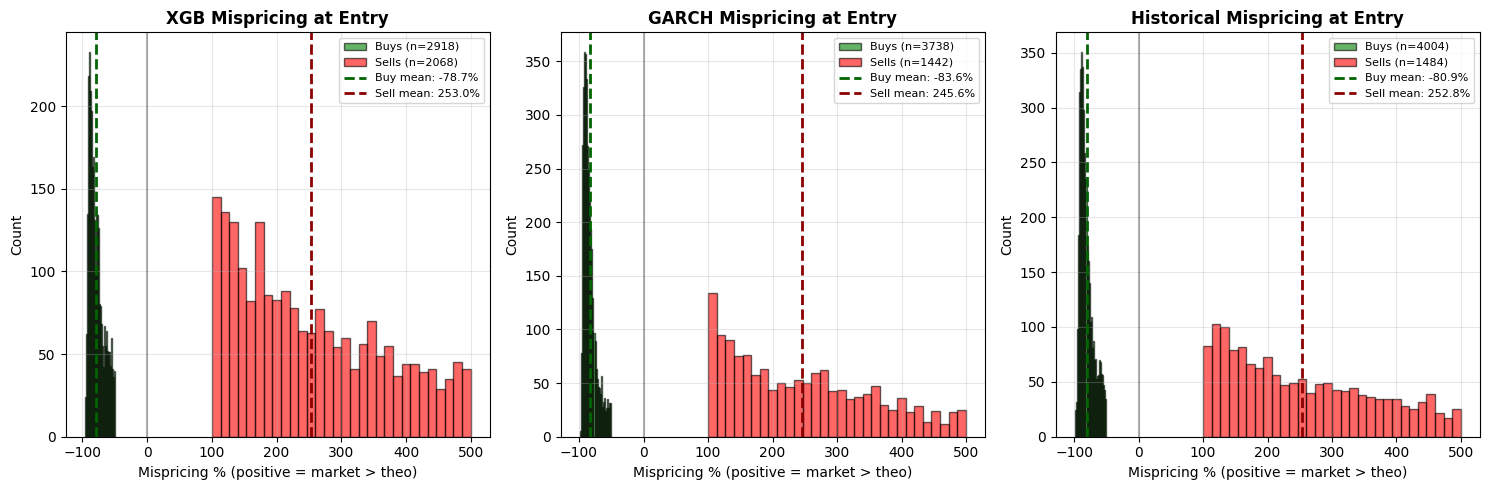

### Mispricing Statistics at Entry

,Strategy,Buy Mean,Buy Median,Sell Mean,Sell Median,Total Entries
0,XGB,-78.7%,-81.9%,253.0%,228.3%,4986
1,GARCH,-83.6%,-86.3%,245.6%,229.8%,5180
2,Historical,-80.9%,-84.1%,252.8%,230.2%,5488


In [52]:
# =============================================================================
# Mispricing at Entry Analysis
# Use logged mispricing if available, otherwise reconstruct
# =============================================================================

def get_mispricing_data(trade_log_df, spy_prices_df, name, r=0.02):
    """
    Get mispricing at entry for option trades.
    Uses logged mispricing_pct if available, otherwise reconstructs from BS.
    """
    options = trade_log_df[trade_log_df['trade_type'] == 'option'].copy()
    options['timestamp'] = pd.to_datetime(options['timestamp'])
    options = options[options['mispricing_pct'].notna()]
    options = options[options['mispricing_pct'].between(-5, 5)]

    return options

# Get mispricing for each strategy (uses logged values if available)
xgb_mispricing = get_mispricing_data(xgb_trade_log_df, spy_prices_df, 'XGB')
garch_mispricing = get_mispricing_data(garch_trade_log_df, spy_prices_df, 'GARCH')
hist_mispricing = get_mispricing_data(historical_trade_log_df, spy_prices_df, 'Historical')

# Create mispricing distribution plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    (xgb_mispricing, 'XGB', '#2ecc71'),
    (garch_mispricing, 'GARCH', '#e74c3c'),
    (hist_mispricing, 'Historical', '#3498db')
]

for ax, (df, name, color) in zip(axes, datasets):
    # Separate buys and sells
    buys = df[df['quantity'] > 0]['mispricing_pct'] * 100
    sells = df[df['quantity'] < 0]['mispricing_pct'] * 100
    
    # Plot histograms
    ax.hist(buys, bins=30, alpha=0.6, color='green', label=f'Buys (n={len(buys)})', edgecolor='black')
    ax.hist(sells, bins=30, alpha=0.6, color='red', label=f'Sells (n={len(sells)})', edgecolor='black')
    
    # Add vertical lines for means
    if len(buys) > 0:
        ax.axvline(buys.mean(), color='darkgreen', linestyle='--', linewidth=2, label=f'Buy mean: {buys.mean():.1f}%')
    if len(sells) > 0:
        ax.axvline(sells.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Sell mean: {sells.mean():.1f}%')
    
    ax.axvline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_title(f'{name} Mispricing at Entry', fontweight='bold')
    ax.set_xlabel('Mispricing % (positive = market > theo)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/mispricing_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
display(Markdown("### Mispricing Statistics at Entry"))
mispricing_summary = []
for df, name, _ in datasets:
    buys = df[df['quantity'] > 0]['mispricing_pct'] * 100
    sells = df[df['quantity'] < 0]['mispricing_pct'] * 100
    mispricing_summary.append({
        'Strategy': name,
        'Buy Mean': f"{buys.mean():.1f}%" if len(buys) > 0 else "N/A",
        'Buy Median': f"{buys.median():.1f}%" if len(buys) > 0 else "N/A",
        'Sell Mean': f"{sells.mean():.1f}%" if len(sells) > 0 else "N/A",
        'Sell Median': f"{sells.median():.1f}%" if len(sells) > 0 else "N/A",
        'Total Entries': len(df)
    })
display(pd.DataFrame(mispricing_summary))

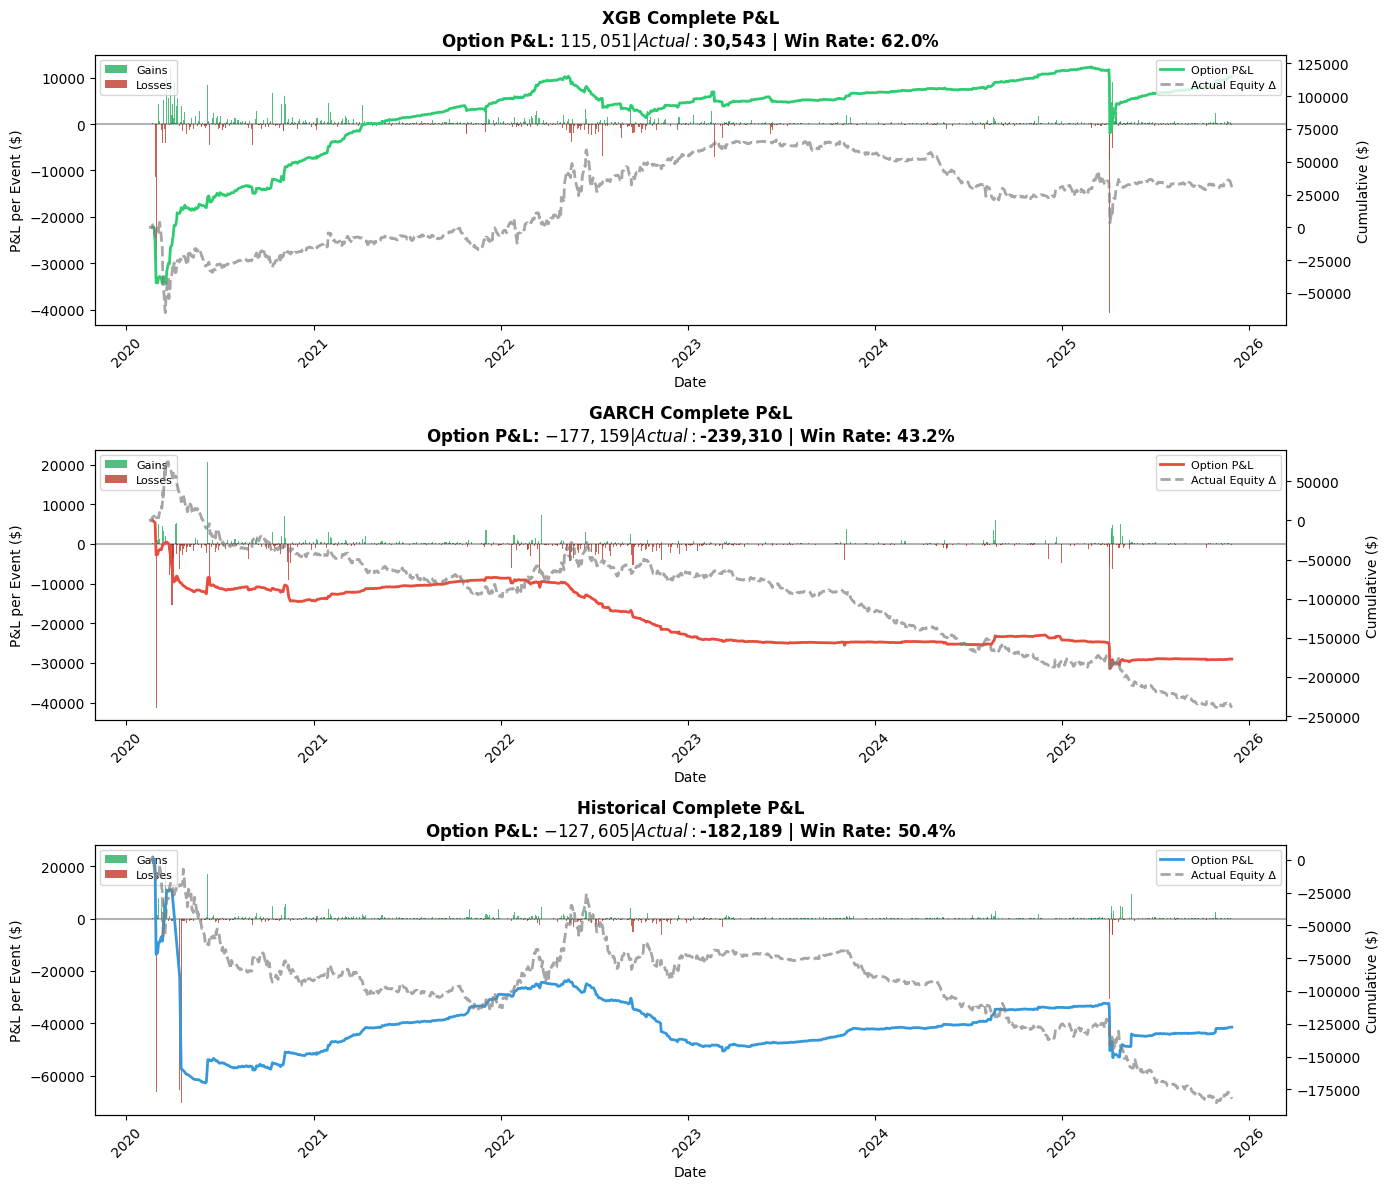

### Complete P&L Reconciliation

,Strategy,Expiry P&L,Early Exit P&L,Total Option P&L,Hedge + Costs,Actual Equity Δ,Win Rate,Expiry Events,Early Exits
0,XGB,"$141,886","$-26,835","$115,051","$-84,508","$30,543",62.0%,1115,218
1,GARCH,"$-66,978","$-110,180","$-177,159","$-62,151","$-239,310",43.2%,1020,77
2,Historical,"$20,193","$-147,798","$-127,605","$-54,584","$-182,189",50.4%,1107,66


### P&L Waterfall Breakdown

,Strategy,1. Expiry P&L,2. Early Exit P&L,3. = 1 + 2 Option Total,4. Hedge + Costs,5. = 3 + 4 Actual Result
0,XGB,"$+141,886","$-26,835","$+115,051","$-84,508","$+30,543"
1,GARCH,"$-66,978","$-110,180","$-177,159","$-62,151","$-239,310"
2,Historical,"$+20,193","$-147,798","$-127,605","$-54,584","$-182,189"


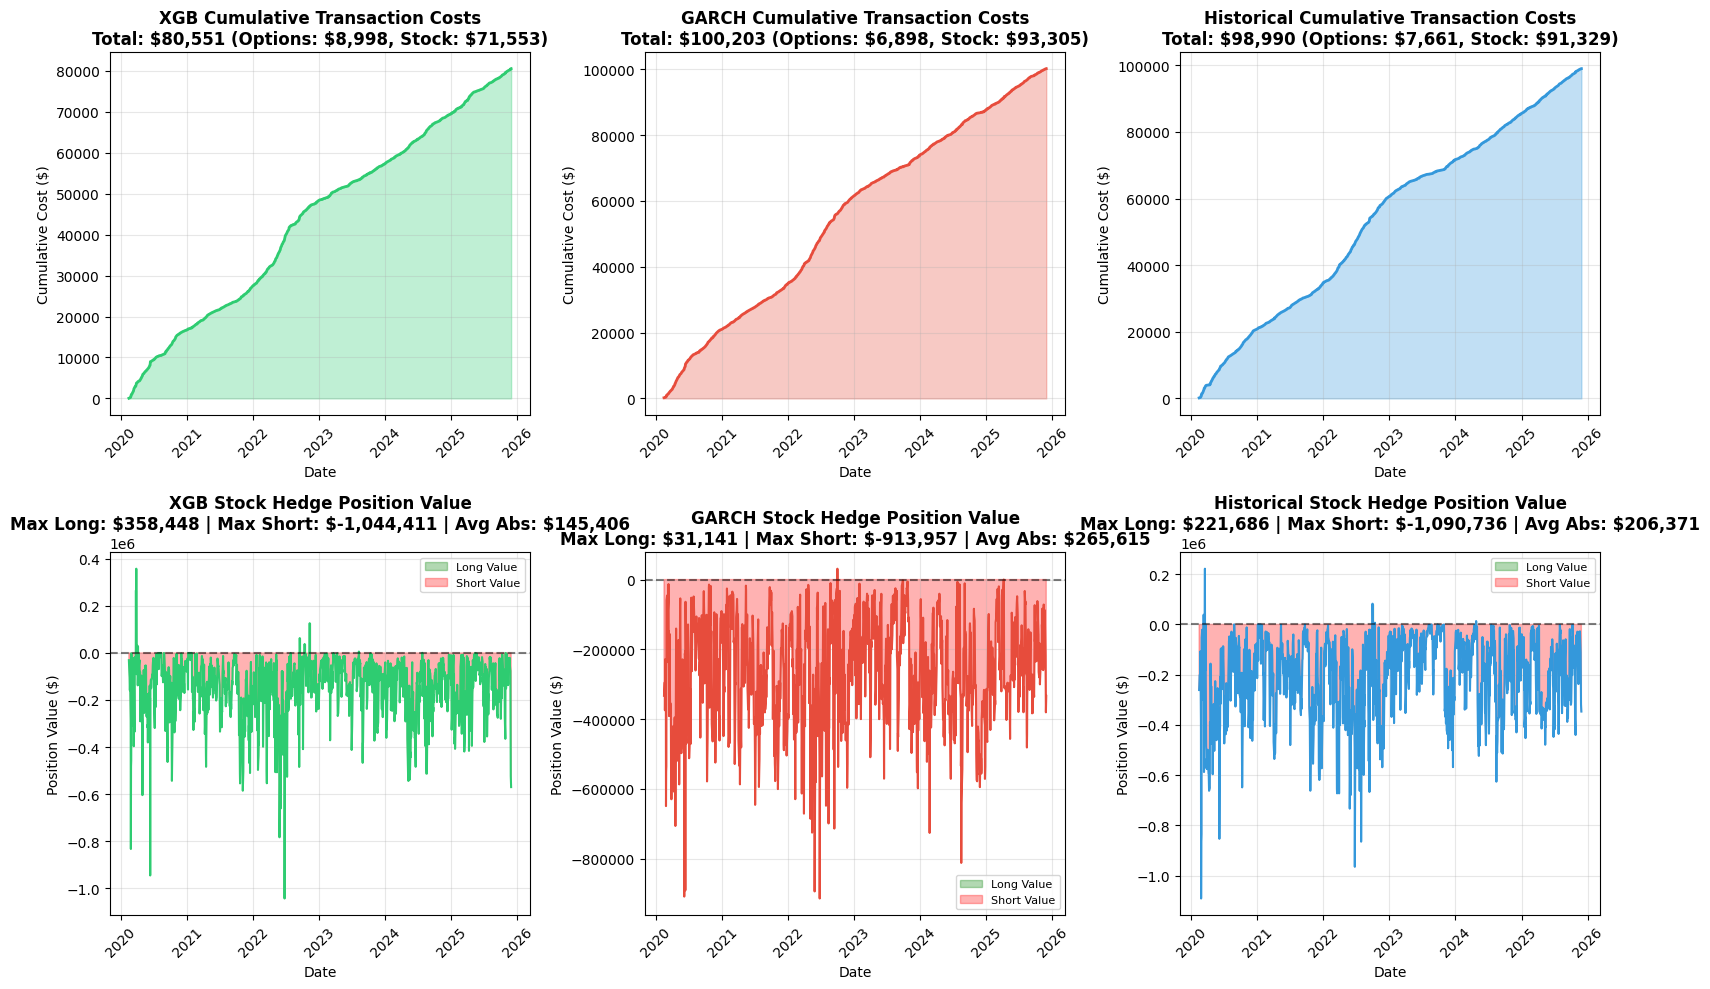

### Transaction Cost Breakdown

,Strategy,Option Costs,Stock Costs,Total Costs,Stock % of Total
0,XGB,"$8,998","$71,553","$80,551",88.8%
1,GARCH,"$6,898","$93,305","$100,203",93.1%
2,Historical,"$7,661","$91,329","$98,990",92.3%


In [50]:
# =============================================================================
# P&L Analysis - Complete Breakdown (Expiry + Early Exit + Hedging)
# Shows all P&L components for accurate strategy evaluation
# =============================================================================

def create_complete_pnl_plot(expiry_df, early_df, equity_df, name, ax, color):
    """Create P&L bar plot combining expiry and early exit events."""
    # Prepare expiry data
    exp = expiry_df.copy()
    exp['date'] = pd.to_datetime(exp['date'])
    exp['source'] = 'expiry'
    
    # Prepare early exit data
    early = early_df.copy()
    early['date'] = pd.to_datetime(early['date'])
    early['source'] = 'early_exit'
    
    # Combine all option P&L events
    combined = pd.concat([
        exp[['date', 'pnl', 'source']],
        early[['date', 'pnl', 'source']]
    ]).sort_values('date')
    
    # Aggregate by date (sum multiple events on same day)
    daily_pnl = combined.groupby('date')['pnl'].sum().reset_index()
    
    # Separate gains and losses
    gains = daily_pnl[daily_pnl['pnl'] > 0]
    losses = daily_pnl[daily_pnl['pnl'] <= 0]
    
    # Plot bars
    ax.bar(gains['date'], gains['pnl'], color='#27ae60', alpha=0.8, label='Gains', width=2)
    ax.bar(losses['date'], losses['pnl'], color='#c0392b', alpha=0.8, label='Losses', width=2)
    
    # Add cumulative P&L line (option P&L only)
    daily_pnl['cumulative_pnl'] = daily_pnl['pnl'].cumsum()
    ax2 = ax.twinx()
    ax2.plot(daily_pnl['date'], daily_pnl['cumulative_pnl'], color=color, linewidth=2, 
             label='Option P&L', linestyle='-')
    
    # Also plot actual equity change for comparison
    eq = equity_df.copy()
    eq['date'] = pd.to_datetime(eq['date'])
    initial_equity = eq['equity'].iloc[0]
    eq['equity_change'] = eq['equity'] - initial_equity
    ax2.plot(eq['date'], eq['equity_change'], color='gray', linewidth=2, 
             alpha=0.7, linestyle='--', label='Actual Equity Δ')
    
    ax2.set_ylabel('Cumulative ($)', color='black')
    ax2.legend(loc='upper right', fontsize=8)
    
    # Calculate stats
    total_option_pnl = combined['pnl'].sum()
    expiry_pnl = exp['pnl'].sum()
    early_pnl = early['pnl'].sum()
    actual_equity_change = eq['equity'].iloc[-1] - initial_equity
    hedge_and_costs = actual_equity_change - total_option_pnl
    
    win_rate = (daily_pnl['pnl'] > 0).mean() * 100
    
    ax.set_title(f'{name} Complete P&L\n'
                 f'Option P&L: ${total_option_pnl:,.0f} | Actual: ${actual_equity_change:,.0f} | '
                 f'Win Rate: {win_rate:.1f}%', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('P&L per Event ($)')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax.legend(loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=45)
    
    return {
        'expiry_pnl': expiry_pnl,
        'early_pnl': early_pnl,
        'total_option_pnl': total_option_pnl,
        'actual_equity_change': actual_equity_change,
        'hedge_and_costs': hedge_and_costs,
        'win_rate': win_rate,
        'n_expiry': len(exp),
        'n_early': len(early)
    }

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

strategies = [
    (xgb_expiry_log_df, xgb_early_exit_df, xgb_equity_df, 'XGB', '#2ecc71'),
    (garch_expiry_log_df, garch_early_exit_df, garch_equity_df, 'GARCH', '#e74c3c'),
    (historical_expiry_log_df, historical_early_exit_df, historical_equity_df, 'Historical', '#3498db')
]

pnl_stats = []
for ax, (expiry_df, early_df, equity_df, name, color) in zip(axes, strategies):
    stats = create_complete_pnl_plot(expiry_df, early_df, equity_df, name, ax, color)
    pnl_stats.append({
        'Strategy': name,
        'Expiry P&L': stats['expiry_pnl'],
        'Early Exit P&L': stats['early_pnl'],
        'Total Option P&L': stats['total_option_pnl'],
        'Hedge + Costs': stats['hedge_and_costs'],
        'Actual Equity Δ': stats['actual_equity_change'],
        'Win Rate': stats['win_rate'],
        'Expiry Events': stats['n_expiry'],
        'Early Exits': stats['n_early']
    })

plt.tight_layout()
plt.savefig('../results/pnl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# Summary Tables
# =============================================================================

display(Markdown("### Complete P&L Reconciliation"))

# Format the summary dataframe
summary_df = pd.DataFrame(pnl_stats)

# Create a formatted version for display
display_df = summary_df.copy()
for col in ['Expiry P&L', 'Early Exit P&L', 'Total Option P&L', 'Hedge + Costs', 'Actual Equity Δ']:
    display_df[col] = display_df[col].apply(lambda x: f"${x:,.0f}")
display_df['Win Rate'] = display_df['Win Rate'].apply(lambda x: f"{x:.1f}%")

display(display_df)

# Waterfall breakdown
display(Markdown("### P&L Waterfall Breakdown"))
waterfall_data = []
for _, row in summary_df.iterrows():
    waterfall_data.append({
        'Strategy': row['Strategy'],
        '1. Expiry P&L': f"${row['Expiry P&L']:+,.0f}",
        '2. Early Exit P&L': f"${row['Early Exit P&L']:+,.0f}",
        '3. = 1 + 2 Option Total': f"${row['Total Option P&L']:+,.0f}",
        '4. Hedge + Costs': f"${row['Hedge + Costs']:+,.0f}",
        '5. = 3 + 4 Actual Result': f"${row['Actual Equity Δ']:+,.0f}"
    })
display(pd.DataFrame(waterfall_data))

# =============================================================================
# Transaction Costs & Stock Position Analysis
# =============================================================================

def calculate_transaction_costs(trade_log_df, option_cost_per_contract=0.50, stock_cost_bps=5):
    """
    Calculate transaction costs from trade log.
    
    Args:
        trade_log_df: DataFrame with trade log
        option_cost_per_contract: Cost per option contract ($)
        stock_cost_bps: Cost in basis points for stock trades
    """
    df = trade_log_df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Calculate costs for each trade
    df['transaction_cost'] = 0.0
    
    # Options: fixed cost per contract
    option_mask = df['trade_type'] == 'option'
    df.loc[option_mask, 'transaction_cost'] = df.loc[option_mask, 'quantity'].abs() * option_cost_per_contract
    
    # Stock: basis points on notional
    stock_mask = df['trade_type'] == 'stock'
    df.loc[stock_mask, 'transaction_cost'] = (
        df.loc[stock_mask, 'quantity'].abs() * 
        df.loc[stock_mask, 'price'] * 
        (stock_cost_bps / 10000)
    )
    
    # Aggregate by date
    daily_costs = df.groupby('timestamp').agg({
        'transaction_cost': 'sum'
    }).reset_index()
    daily_costs.columns = ['date', 'daily_cost']
    daily_costs['cumulative_cost'] = daily_costs['daily_cost'].cumsum()
    
    # Separate option vs stock costs
    option_costs = df[option_mask].groupby('timestamp')['transaction_cost'].sum().reset_index()
    option_costs.columns = ['date', 'option_cost']
    stock_costs = df[stock_mask].groupby('timestamp')['transaction_cost'].sum().reset_index()
    stock_costs.columns = ['date', 'stock_cost']
    
    return daily_costs, option_costs, stock_costs, df

def calculate_stock_position_value(trade_log_df, spy_prices_df):
    """
    Calculate cumulative stock position value over time.
    """
    df = trade_log_df[trade_log_df['trade_type'] == 'stock'].copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp')
    
    # Get daily stock position (cumulative)
    daily_pos = df.groupby('timestamp')['quantity'].sum().cumsum().reset_index()
    daily_pos.columns = ['date', 'shares']
    
    # Merge with SPY prices to get position value
    spy = spy_prices_df[['date', 'close']].copy()
    spy['date'] = pd.to_datetime(spy['date'])
    
    merged = daily_pos.merge(spy, on='date', how='left')
    merged['close'] = merged['close'].ffill()  # Forward fill missing prices
    merged['position_value'] = merged['shares'] * merged['close']
    
    return merged

# Create figure for transaction costs (3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

trade_logs = [
    (xgb_trade_log_df, 'XGB', '#2ecc71'),
    (garch_trade_log_df, 'GARCH', '#e74c3c'),
    (historical_trade_log_df, 'Historical', '#3498db')
]

cost_summary = []

for idx, (trade_log, name, color) in enumerate(trade_logs):
    # --- Row 1: Transaction Costs ---
    ax = axes[0, idx]
    
    daily_costs, option_costs, stock_costs, detailed = calculate_transaction_costs(trade_log)
    
    # Plot cumulative costs
    ax.fill_between(daily_costs['date'], 0, daily_costs['cumulative_cost'], 
                    alpha=0.3, color=color)
    ax.plot(daily_costs['date'], daily_costs['cumulative_cost'], 
            color=color, linewidth=2, label='Total Costs')
    
    # Add option vs stock breakdown as stacked area
    total_option_cost = detailed[detailed['trade_type'] == 'option']['transaction_cost'].sum()
    total_stock_cost = detailed[detailed['trade_type'] == 'stock']['transaction_cost'].sum()
    total_cost = daily_costs['cumulative_cost'].iloc[-1]
    
    ax.set_title(f'{name} Cumulative Transaction Costs\n'
                 f'Total: ${total_cost:,.0f} (Options: ${total_option_cost:,.0f}, Stock: ${total_stock_cost:,.0f})', 
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Cost ($)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    
    cost_summary.append({
        'Strategy': name,
        'Option Costs': total_option_cost,
        'Stock Costs': total_stock_cost,
        'Total Costs': total_cost,
        'Stock % of Total': total_stock_cost / total_cost * 100 if total_cost > 0 else 0
    })
    
    # --- Row 2: Stock Position Value ---
    ax2 = axes[1, idx]
    
    stock_pos = calculate_stock_position_value(trade_log, spy_prices_df)
    
    # Plot position value with fill
    ax2.fill_between(stock_pos['date'], 0, stock_pos['position_value'],
                     where=(stock_pos['position_value'] >= 0), alpha=0.3, color='green', label='Long Value')
    ax2.fill_between(stock_pos['date'], 0, stock_pos['position_value'],
                     where=(stock_pos['position_value'] < 0), alpha=0.3, color='red', label='Short Value')
    ax2.plot(stock_pos['date'], stock_pos['position_value'], color=color, linewidth=1.5)
    
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Stats
    max_long = stock_pos['position_value'].max()
    max_short = stock_pos['position_value'].min()
    avg_abs = stock_pos['position_value'].abs().mean()
    
    ax2.set_title(f'{name} Stock Hedge Position Value\n'
                  f'Max Long: ${max_long:,.0f} | Max Short: ${max_short:,.0f} | Avg Abs: ${avg_abs:,.0f}',
                  fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Position Value ($)')
    ax2.legend(loc='best', fontsize=8)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/costs_and_hedge_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Cost Summary Table ---
display(Markdown("### Transaction Cost Breakdown"))
cost_df = pd.DataFrame(cost_summary)
cost_display = cost_df.copy()
for col in ['Option Costs', 'Stock Costs', 'Total Costs']:
    cost_display[col] = cost_display[col].apply(lambda x: f"${x:,.0f}")
cost_display['Stock % of Total'] = cost_display['Stock % of Total'].apply(lambda x: f"{x:.1f}%")
display(cost_display)

